# Inspect Cluster Lifecycle Report

This notebook loads a `graphcluster` lifecycle report artifact written during a streaming run and gives a quick way to inspect the most useful data without rerunning the trajectory pipeline.

The current report artifact contains:
- trajectory-level summary counts
- per-frame cluster counts and changed-atom counts
- birth, death, split, and merge events
- per-atom switch counts
- simple cluster lifetime records


In [1]:
import sys
print(sys.executable)

/n/home12/lsteinberger/.conda/envs/nequip311/bin/python


In [2]:
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt

from graphcluster.analysis.lifecycle_report import ClusterLifecycleReport

# Change this path if you want to inspect a different run.
REPORT_PATH = Path("/n/home12/lsteinberger/graphcluster/outputs/toy_debug/cluster_lifecycle_report.jsonl")

if not REPORT_PATH.exists():
    raise FileNotFoundError(f"Could not find report artifact: {REPORT_PATH}")

report = ClusterLifecycleReport.from_path(REPORT_PATH)
REPORT_PATH

PosixPath('/n/home12/lsteinberger/graphcluster/outputs/toy_debug/cluster_lifecycle_report.jsonl')

In [3]:
print("Source:", report.source_path)
print("Summary:")
pprint(report.summary)

Source: /n/home12/lsteinberger/graphcluster/outputs/toy_debug/cluster_lifecycle_report.jsonl
Summary:
{'num_atoms': 129,
 'num_frames': 5,
 'num_tracked_clusters': 10,
 'total_births': 10,
 'total_deaths': 4,
 'total_merges': 15,
 'total_splits': 11}


In [4]:
births = report.get_births()
deaths = report.get_deaths()
splits = report.get_splits()
merges = report.get_merges()

print("Birth frames:", len(births))
print("Death frames:", len(deaths))
print("Split frames:", len(splits))
print("Merge frames:", len(merges))

print("\nFirst few birth events:")
pprint(births[:3])

print("\nFirst few death events:")
pprint(deaths[:3])

print("\nFirst split frame:")
pprint(splits[:1])

print("\nFirst merge frame:")
pprint(merges[:1])

Birth frames: 3
Death frames: 2
Split frames: 4
Merge frames: 4

First few birth events:
[{'cluster_ids': [0, 1, 2, 3, 4, 5], 'frame_index': 0},
 {'cluster_ids': [6], 'frame_index': 1},
 {'cluster_ids': [7, 8, 9], 'frame_index': 2}]

First few death events:
[{'cluster_ids': [4, 5], 'frame_index': 1},
 {'cluster_ids': [3, 6], 'frame_index': 2}]

First split frame:
[{'events': [{'current_cluster_ids': [0, 1, 3], 'previous_cluster_id': 0},
             {'current_cluster_ids': [0, 2, 6], 'previous_cluster_id': 2},
             {'current_cluster_ids': [2, 3, 6], 'previous_cluster_id': 4}],
  'frame_index': 1}]

First merge frame:
[{'events': [{'current_cluster_id': 0, 'previous_cluster_ids': [0, 2]},
             {'current_cluster_id': 1, 'previous_cluster_ids': [0, 1]},
             {'current_cluster_id': 2, 'previous_cluster_ids': [1, 2]},
             {'current_cluster_id': 3, 'previous_cluster_ids': [0, 3]},
             {'current_cluster_id': 6, 'previous_cluster_ids': [2, 4, 5]}],
  '

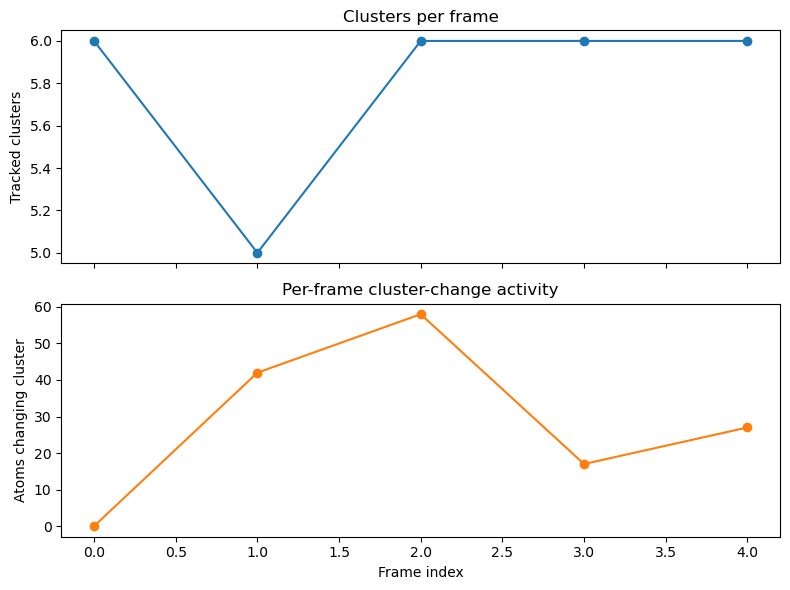

In [5]:
frame_counts = report.get_frame_cluster_counts()
frame_indices = [record["frame_index"] for record in frame_counts]
num_clusters = [record["num_clusters"] for record in frame_counts]
num_changed_atoms = [record["num_changed_atoms"] for record in frame_counts]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(frame_indices, num_clusters, marker="o")
axes[0].set_ylabel("Tracked clusters")
axes[0].set_title("Clusters per frame")

axes[1].plot(frame_indices, num_changed_atoms, marker="o", color="tab:orange")
axes[1].set_xlabel("Frame index")
axes[1].set_ylabel("Atoms changing cluster")
axes[1].set_title("Per-frame cluster-change activity")

fig.tight_layout()
plt.show()

Number of atoms: 129
Max switch count: 4
Atoms with at least one switch: 85


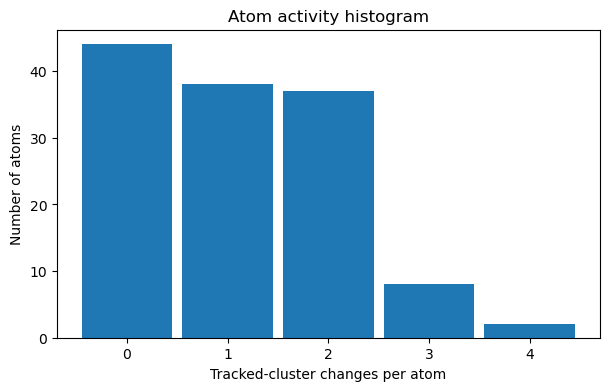

In [6]:
atom_switch_counts = report.get_atom_switch_counts()

print("Number of atoms:", len(atom_switch_counts))
print("Max switch count:", max(atom_switch_counts) if atom_switch_counts else 0)
print("Atoms with at least one switch:", sum(count > 0 for count in atom_switch_counts))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(atom_switch_counts, bins=range(0, max(atom_switch_counts) + 2 if atom_switch_counts else 2), align="left", rwidth=0.9)
ax.set_xlabel("Tracked-cluster changes per atom")
ax.set_ylabel("Number of atoms")
ax.set_title("Atom activity histogram")
plt.show()

Top cluster lifetimes:
[{'cluster_id': 0,
  'first_seen_frame': 0,
  'frames_observed': 5,
  'last_seen_frame': 4},
 {'cluster_id': 1,
  'first_seen_frame': 0,
  'frames_observed': 5,
  'last_seen_frame': 4},
 {'cluster_id': 2,
  'first_seen_frame': 0,
  'frames_observed': 5,
  'last_seen_frame': 4},
 {'cluster_id': 7,
  'first_seen_frame': 2,
  'frames_observed': 3,
  'last_seen_frame': 4},
 {'cluster_id': 8,
  'first_seen_frame': 2,
  'frames_observed': 3,
  'last_seen_frame': 4},
 {'cluster_id': 9,
  'first_seen_frame': 2,
  'frames_observed': 3,
  'last_seen_frame': 4},
 {'cluster_id': 3,
  'first_seen_frame': 0,
  'frames_observed': 2,
  'last_seen_frame': 1},
 {'cluster_id': 4,
  'first_seen_frame': 0,
  'frames_observed': 1,
  'last_seen_frame': 0},
 {'cluster_id': 5,
  'first_seen_frame': 0,
  'frames_observed': 1,
  'last_seen_frame': 0},
 {'cluster_id': 6,
  'first_seen_frame': 1,
  'frames_observed': 1,
  'last_seen_frame': 1}]


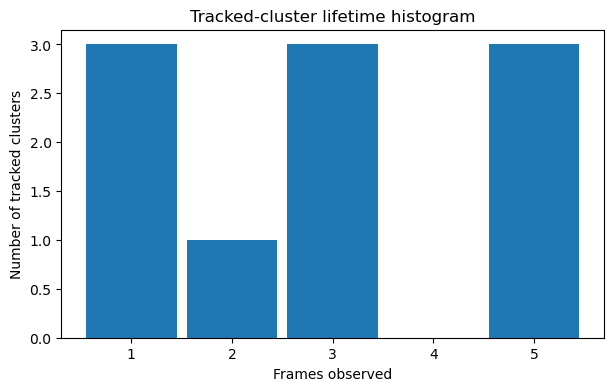

In [7]:
cluster_lifetimes = report.get_cluster_lifetimes()
cluster_lifetimes_sorted = sorted(cluster_lifetimes, key=lambda record: record["frames_observed"], reverse=True)

print("Top cluster lifetimes:")
pprint(cluster_lifetimes_sorted[:10])

lifetime_lengths = [record["frames_observed"] for record in cluster_lifetimes_sorted]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lifetime_lengths, bins=range(1, max(lifetime_lengths) + 2 if lifetime_lengths else 2), align="left", rwidth=0.9)
ax.set_xlabel("Frames observed")
ax.set_ylabel("Number of tracked clusters")
ax.set_title("Tracked-cluster lifetime histogram")
plt.show()

## Next ideas

Natural extensions for this notebook later:
- filter events for a specific frame or tracked cluster
- compare report events against the visualization artifact for the same frame
- plot match-confidence distributions once those are exposed on the report facade
- export selected tables to CSV for external analysis
